# **Renk Uzayları**

Bu derste şunları öğreneceğiz:
1. Bir RGB Görüntüsünün tek tek kanallarını görüntüleme
2. Bir renk uzayını değiştirme
3. HSV Renk Uzaylarını tanıtma

In [1]:
# Kurulumumuz, Kütüphaneleri içe aktarma, imshow fonksiyonumuzu oluşturma ve resimlerimizi indirme
import cv2
import numpy as np
from matplotlib import pyplot as plt

def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

In [2]:
# Girdi resmimizi yükle
image = cv2.imread('../files/images/dursun.jpg')

# Her bir renk uzayını ayrı ayrı elde etmek için cv2.split kullanın
B, G, R = cv2.split(image)
print(B.shape)
print(G.shape)
print(R.shape)

(159, 318)
(159, 318)
(159, 318)


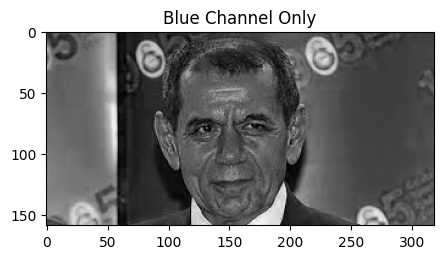

In [3]:
#Her renk uzayı kendi başına, diğer renk kanalları eksik olduğundan gri tonlamalı gibi görünecektir.
imshow("Blue Channel Only", B)

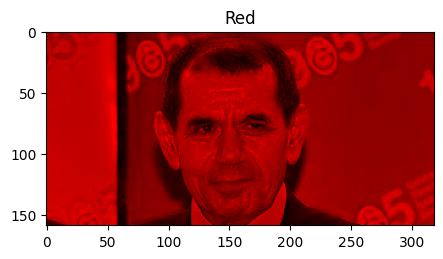

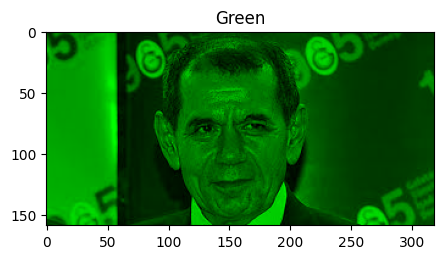

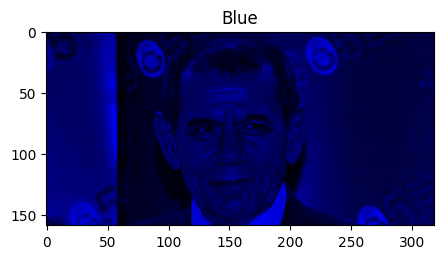

In [4]:
import numpy as np

# h x w boyutlarında sıfırlardan oluşan bir matris oluşturalım  
zeros = np.zeros(image.shape[:2], dtype = "uint8")

# ve her kanalı kendi rebginde görüntüleyelim
imshow("Red", cv2.merge([zeros, zeros, R]))
imshow("Green", cv2.merge([zeros, G, zeros]))
imshow("Blue", cv2.merge([B, zeros, zeros]))

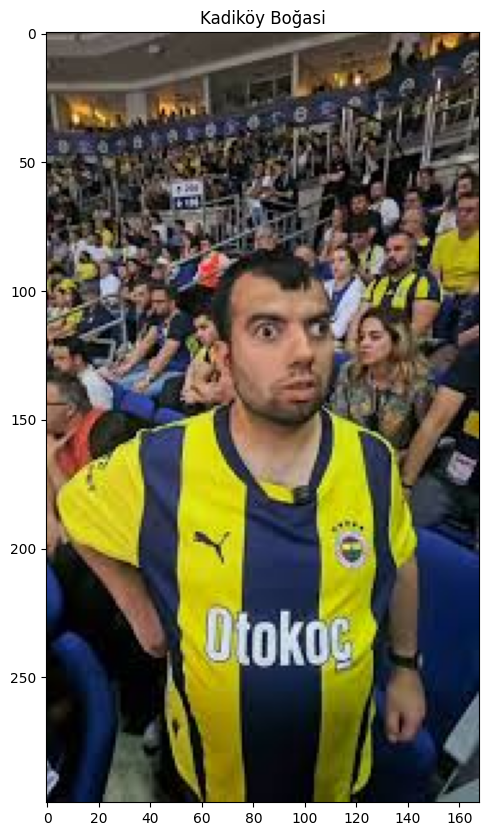

In [5]:
image = cv2.imread('../files/images/kadikoy.jpg')

#OpenCV'nin 'split' fonksiyonu, görüntüyü her renk indeksine ayırır.
B, G, R = cv2.split(image)

#Orijinal görüntüyü yeniden yapalım. 
merged = cv2.merge([B, G, R]) 
imshow("Kadiköy Boğasi", merged) 

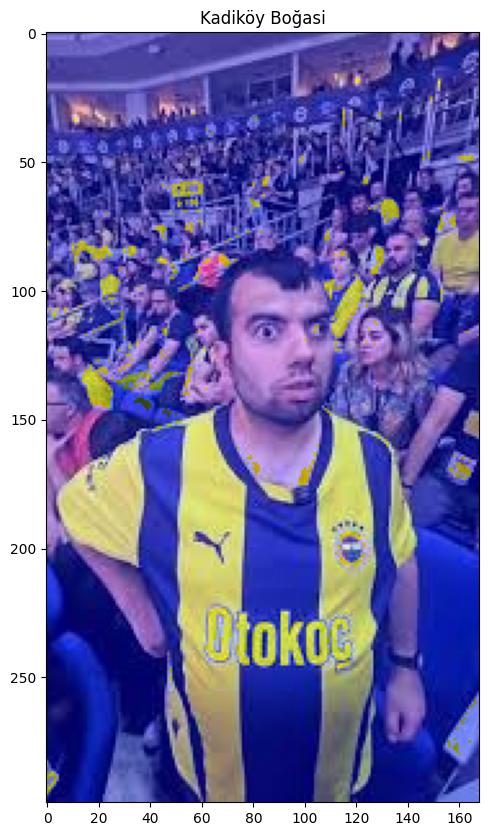

In [16]:
#Mavi rengi güçlendirelim.
merged = cv2.merge([B+100, G, R])
imshow("Kadiköy Boğasi", merged)

## **The HSV Color Space**

![](https://upload.wikimedia.org/wikipedia/commons/f/f2/HSV_color_solid_cone.png)

- Hue(Renk Özü): 0 - 179 
- Saturation(Doygunluk): 0 - 255
- Value (Intensity) (Değer (Yoğunluk)): 0 - 255

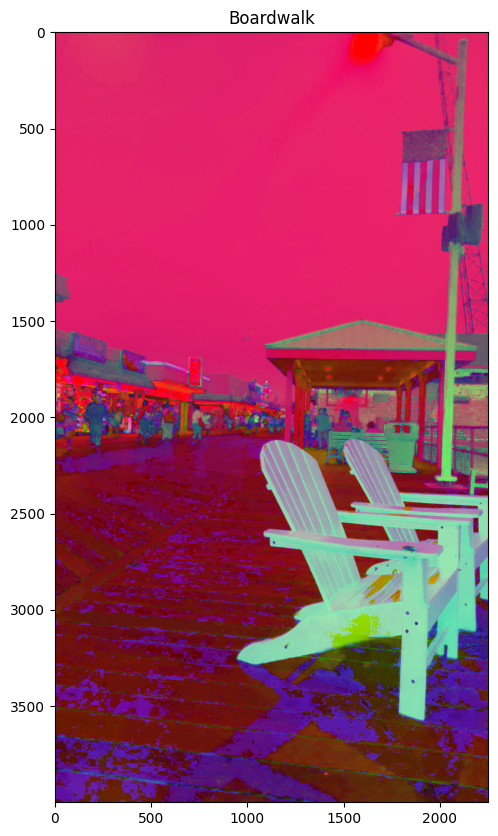

In [17]:
# Resmi yeniden yükleyelim
image = cv2.imread('../files/images/america1.jpg')

# HSV’ye Dönüştür
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
imshow('Boardwalk', hsv_image)

#### Bu garip görünüyor....neden?

Çünkü çizim fonksiyonumuz sadece RGB görüntüler için tasarlanmıştır, HSV için değil.

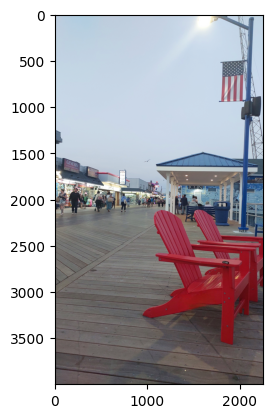

In [18]:
plt.imshow(cv2.cvtColor(hsv_image, cv2.COLOR_HSV2RGB))
plt.show()

### **HSV Renk Uzayı gösteriminde her kanal türünü görüntüleyelim**

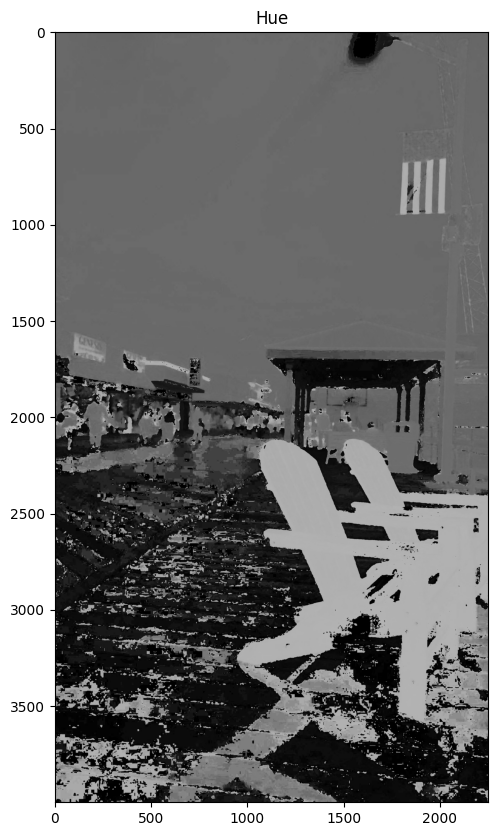

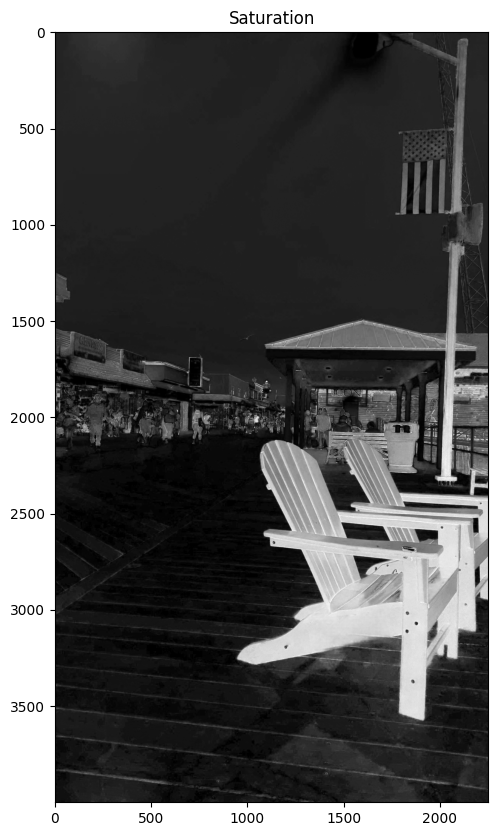

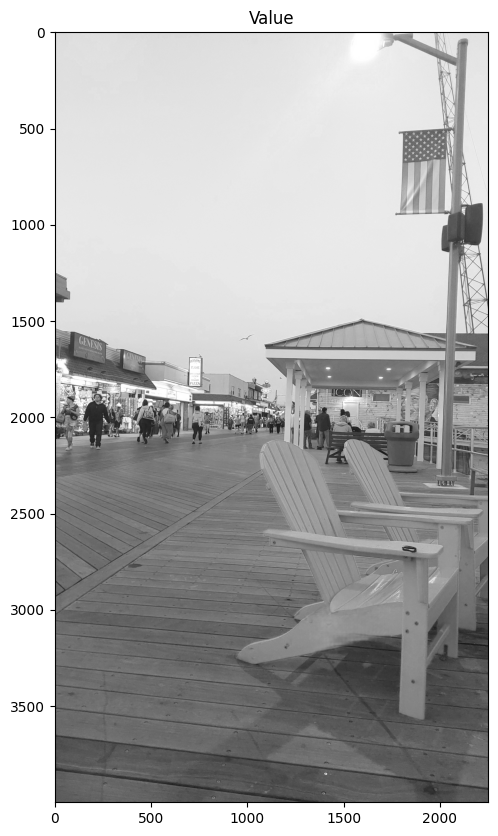

In [19]:
#RGB gösterimine geri dönme
imshow("Hue", hsv_image[:, :, 0])
imshow("Saturation", hsv_image[:, :, 1])
imshow("Value", hsv_image[:, :, 2])